To detect faces, we'll use OpenCV's built-in Haar Cascade classifiers. First, you'll need to download the `haarcascade_frontalface_default.xml` file. You can typically find this file in the OpenCV data directory, or download it from the OpenCV GitHub repository (e.g., `https://github.com/opencv/opencv/blob/master/data/haarcascades/haarcascade_frontalface_default.xml`).

**Before running the code, make sure to upload this XML file to your Colab environment or provide the correct path to it.**

In [1]:
import cv2
import matplotlib.pyplot as plt

def count_faces(image_path, cascade_path='haarcascade_frontalface_default.xml'):
    """
    Counts the number of faces in a given image using OpenCV's Haar Cascade classifier.

    Args:
        image_path (str): The path to the input image file.
        cascade_path (str): The path to the Haar Cascade XML file for face detection.

    Returns:
        int: The number of faces detected in the image.
        None: If the image or cascade file cannot be loaded.
    """
    # Load the pre-trained Haar Cascade classifier for face detection
    face_cascade = cv2.CascadeClassifier(cascade_path)

    if face_cascade.empty():
        print(f"Error: Could not load face cascade from {cascade_path}")
        return None

    # Read the input image
    img = cv2.imread(image_path)

    if img is None:
        print(f"Error: Could not load image from {image_path}")
        return None

    # Convert the image to grayscale (Haar cascades work better on grayscale)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Detect faces in the grayscale image
    # scaleFactor: Parameter specifying how much the image size is reduced at each image scale.
    # minNeighbors: Parameter specifying how many neighbors each candidate rectangle should have to retain it.
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))

    # Optionally, draw rectangles around the detected faces and display the image
    for (x, y, w, h) in faces:
        cv2.rectangle(img, (x, y), (x + w, y + h), (255, 0, 0), 2)

    # Display the image with detected faces
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f"Detected Faces: {len(faces)}")
    plt.axis('off')
    plt.show()

    # Return the number of faces detected
    return len(faces)

# Example usage (replace 'your_image.jpg' with your image path)
# You'll need to upload an image and the haarcascade_frontalface_default.xml file to your Colab environment.
# For testing, let's assume 'test_image.jpg' and 'haarcascade_frontalface_default.xml' are in the same directory.

# To demonstrate, let's create a dummy image first (you would replace this with your actual image file)
import numpy as np
dummy_image = np.zeros((300, 500, 3), dtype=np.uint8)
cv2.putText(dummy_image, "Hello Colab!", (50, 150), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)
cv2.imwrite('dummy_image.jpg', dummy_image)

# Now, call the function
# face_count = count_faces('dummy_image.jpg') # This will likely return 0 as it's not a real face
# print(f"Total faces detected: {face_count}")

# For a more realistic test, you would use an image with faces.
# Make sure to upload 'haarcascade_frontalface_default.xml' and your_face_image.jpg
# face_count_real = count_faces('your_face_image.jpg', 'haarcascade_frontalface_default.xml')
# print(f"Total faces detected in real image: {face_count_real}")


True

'haarcascade_frontalface_default.xml' not found. Downloading it...
'haarcascade_frontalface_default.xml' downloaded successfully.


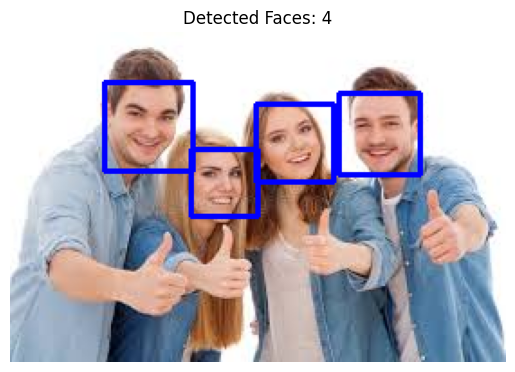

Total faces detected in 'huma image.jpeg': 4


In [3]:
import os
import urllib.request

image_file = 'huma image.jpeg'
cascade_file = 'haarcascade_frontalface_default.xml'

# Check if the cascade file exists, if not, download it
if not os.path.exists(cascade_file):
    print(f"'{cascade_file}' not found. Downloading it...")
    cascade_url = 'https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_frontalface_default.xml'
    try:
        urllib.request.urlretrieve(cascade_url, cascade_file)
        print(f"'{cascade_file}' downloaded successfully.")
    except Exception as e:
        print(f"Error downloading '{cascade_file}': {e}")
        print("Please ensure you have an active internet connection or manually upload the file.")

# Proceed with face counting only if the cascade file is available
if os.path.exists(cascade_file):
    face_count = count_faces(image_file, cascade_file)

    if face_count is not None:
        print(f"Total faces detected in '{image_file}': {face_count}")
else:
    print(f"Cannot proceed with face detection: '{cascade_file}' is still missing.")